In [1]:
import warnings
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf # for OLS (smf.ols)
from sklearn.metrics import mean_squared_error, mean_absolute_error # perform mean-squared for RMSE and MAE
from statsmodels.stats.anova import anova_lm # perform Chi-squared test


# IGNORE WARNINGS
warnings.filterwarnings("ignore")

# LOAD DATA

# 1. base data
train = pd.read_csv("data/GDP_Forecast_train.csv")
test  = pd.read_csv("data/GDP_Forecast_test.csv")
gdp_pca = pd.read_csv("data/GDP_PCA_for_test.csv") # validation data for test

# 2. non-financial external indicators
indpro = pd.read_csv("data/INDPRO_PC1.csv")
unrate = pd.read_csv("data/UNRATE_CH1.csv")

# 3. financial external indicators
compustat = pd.read_csv("data/compustat_quarterly_financials2.csv")




In [2]:
## CONVERT YEAR-QUARTER: SPLIT COLUMNS

# ensure year is an integer
train["year"] = train["YQ"].str[:4].astype(int)
test["year"] = test["YQ"].str[:4].astype(int)

# keep qtr as string / category
train["qtr"] = train["YQ"].str[4:]
test["qtr"] = test["YQ"].str[4:]

In [3]:
## USING SEPARATE gdp_pca DATASET FOR gdp_pcaING RMSE
# we are using a different dataset for gdp_pca because we want to calculate RMSE before submitting

# convert the data to YQ, year and quarter
gdp_pca["observation_date"] = pd.to_datetime(gdp_pca["observation_date"], dayfirst = True)
gdp_pca["year"] = gdp_pca["observation_date"].dt.year
gdp_pca["qtr"] = "Q" + gdp_pca["observation_date"].dt.quarter.astype(str)
gdp_pca["YQ"] = gdp_pca["year"].astype(str) + gdp_pca["qtr"]

# remove observation_date column and move GDP to the back while changing col name to NGDP
gdp_pca.drop(columns = "observation_date", inplace = True)
col = gdp_pca.pop("GDP_PCA")
gdp_pca["NGDP"] = col

# get the quarterly
gdp_pca.sort_values(by = "YQ")

# # check data for 1990 - 2015 is similar to train to continue with this dataset for gdp_pca
# gdp_pca[gdp_pca["year"] <= 2015].transpose()
## NOTE: data from later years is not as accurate, but we will use this to tentatively gdp_pca our RMSE
gdp_pca = gdp_pca[gdp_pca["year"]>= 2016].reset_index(drop = True)

## PREVIEWING OF GDP_PCA (VALIDATION ONLY)

print("GDP_PCA preview:")
print(gdp_pca.head(8))
print(gdp_pca.tail(8))
print("\nGDP_PCA info:")
print("Number of rows:", len(gdp_pca))
print("Number of unique quarters:", gdp_pca["YQ"].nunique())
print("Any missing YQ?", gdp_pca["YQ"].isna().any())
print("Any missing GDP_PCA?", gdp_pca["NGDP"].isna().any())
print("\nCheck duplicate quarters in GDP_PCA:", gdp_pca["YQ"].duplicated().sum())

GDP_PCA preview:
   year qtr      YQ  NGDP
0  2016  Q1  2016Q1   2.0
1  2016  Q2  2016Q2   4.1
2  2016  Q3  2016Q3   3.9
3  2016  Q4  2016Q4   4.2
4  2017  Q1  2017Q1   4.1
5  2017  Q2  2017Q2   3.3
6  2017  Q3  2017Q3   5.3
7  2017  Q4  2017Q4   7.2
    year qtr      YQ  NGDP
12  2019  Q1  2019Q1   3.8
13  2019  Q2  2019Q2   5.5
14  2019  Q3  2019Q3   6.1
15  2019  Q4  2019Q4   4.0
16  2020  Q1  2020Q1  -3.3
17  2020  Q2  2020Q2 -29.1
18  2020  Q3  2020Q3  39.9
19  2020  Q4  2020Q4   7.2

GDP_PCA info:
Number of rows: 20
Number of unique quarters: 20
Any missing YQ? False
Any missing GDP_PCA? False

Check duplicate quarters in GDP_PCA: 0


In [4]:
## DEFINE FUNCTIONS FOR REUSE

def calc_performance(formula1, model1, formula2, model2):
    print(pd.DataFrame({'model'   : [formula1, formula2],
                    'Adj.R^2' : [model1.rsquared_adj, model2.rsquared_adj]}))
    print()
    print(anova_lm(model1, model2, test = "Chisq"))

def create_submission(test_df, y_pred, filename):
    df = pd.DataFrame({"YQ": test_df["YQ"], "NGDP": y_pred})
    df.to_csv(f"attempts/{filename}.csv", index = False)

Base Model

In [5]:
## CONVERT TO COMMON QUARTER KEY

train["quarter"] = pd.PeriodIndex(train["YQ"], freq = "Q")
test["quarter"]  = pd.PeriodIndex(test["YQ"],  freq = "Q")


## CREATE LAG VARIABLE

# sort training data by quarter before creating lag
train = train.sort_values(by = "quarter").reset_index(drop = True)

# create 1-quarter lag of NGDP
train["NGDP_lag1"] = train["NGDP"].shift(1)

# remove first row with missing lag
train_model = train.dropna().copy()


## FIT BASE MODEL
# NGDP_t = a + b * NGDP_(t-1)

import statsmodels.api as sm

X = sm.add_constant(train_model["NGDP_lag1"])
y = train_model["NGDP"]

model_base = sm.OLS(y, X).fit()

print(model_base.summary())


                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     24.00
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           3.68e-06
Time:                        18:30:08   Log-Likelihood:                -237.24
No. Observations:                 103   AIC:                             478.5
Df Residuals:                     101   BIC:                             483.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5247      0.479      5.273      0.0

In [6]:
## RECURSIVE FORECASTING USING BASE MODEL
# use last observed NGDP from training set as the starting lag

test = test.sort_values(by = "quarter").reset_index(drop = True)

base_forecast = []

last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test)):
    
    X_new = pd.DataFrame({
        "const"     : [1],
        "NGDP_lag1" : [last_ngdp]
    })
    
    pred = model_base.predict(X_new)[0]
    
    base_forecast.append(pred)
    
    # update lag for next quarter
    last_ngdp = pred

test["base_forecast"] = base_forecast


## PREVIEW FORECAST RESULTS

print("Base forecast preview:")
print(test[["YQ", "base_forecast"]].head(8))
print(test[["YQ", "base_forecast"]].tail(8))

Base forecast preview:
       YQ  base_forecast
0  2016Q1       2.743384
1  2016Q2       3.724569
2  2016Q3       4.153708
3  2016Q4       4.341400
4  2017Q1       4.423491
5  2017Q2       4.459395
6  2017Q3       4.475098
7  2017Q4       4.481966
        YQ  base_forecast
12  2019Q1       4.487220
13  2019Q2       4.487268
14  2019Q3       4.487289
15  2019Q4       4.487298
16  2020Q1       4.487302
17  2020Q2       4.487304
18  2020Q3       4.487304
19  2020Q4       4.487305


The base model produces forecasts that converge rapidly to a stable long-run level, reflecting the autoregressive persistence structure of the model. While the model performs reasonably during relatively stable periods, it fails to capture the sharp contraction and rebound in 2020, leading to a comparatively high RMSE. This suggests that lagged NGDP alone is insufficient for modelling substantial macroeconomic fluctuations, thereby motivating the introduction of external leading indicators in the subsequent specification.

In [7]:
## VALIDATE BASE MODEL FORECAST AGAINST GDP_PCA

# keep only the predicted values needed for validation
base_validation = test[["YQ", "base_forecast"]].merge(
    gdp_pca[["YQ", "NGDP"]],
    on = "YQ",
    how = "left"
)

# rename columns clearly
base_validation.rename(columns = {
    "base_forecast" : "NGDP_pred",
    "NGDP"          : "NGDP_actual"
}, inplace = True)


## CALCULATE RMSE AND MAE

rmse_base = np.sqrt(mean_squared_error(
    base_validation["NGDP_actual"],
    base_validation["NGDP_pred"]
))

mae_base = mean_absolute_error(
    base_validation["NGDP_actual"],
    base_validation["NGDP_pred"]
)

print("Base model RMSE:", round(rmse_base, 4))
print("Base model MAE :", round(mae_base, 4))


## PREVIEW VALIDATION TABLE

print("\nBase validation preview:")
print(base_validation.head(8))
print(base_validation.tail(8))
print("\nAny missing actual values?", base_validation["NGDP_actual"].isna().any())
print("Any missing predicted values?", base_validation["NGDP_pred"].isna().any())

Base model RMSE: 11.1175
Base model MAE : 4.7121

Base validation preview:
       YQ  NGDP_pred  NGDP_actual
0  2016Q1   2.743384          2.0
1  2016Q2   3.724569          4.1
2  2016Q3   4.153708          3.9
3  2016Q4   4.341400          4.2
4  2017Q1   4.423491          4.1
5  2017Q2   4.459395          3.3
6  2017Q3   4.475098          5.3
7  2017Q4   4.481966          7.2
        YQ  NGDP_pred  NGDP_actual
12  2019Q1   4.487220          3.8
13  2019Q2   4.487268          5.5
14  2019Q3   4.487289          6.1
15  2019Q4   4.487298          4.0
16  2020Q1   4.487302         -3.3
17  2020Q2   4.487304        -29.1
18  2020Q3   4.487304         39.9
19  2020Q4   4.487305          7.2

Any missing actual values? False
Any missing predicted values? False


Model with non-financial external indicators (MACRO INDICATOR MODEL)

In [8]:
## CONVERT NON-FINANCIAL EXTERNAL INDICATORS TO COMMON QUARTER FORMAT

# convert observation_date to datetime
indpro["observation_date"] = pd.to_datetime(indpro["observation_date"], format = "mixed", dayfirst = True)
unrate["observation_date"] = pd.to_datetime(unrate["observation_date"], format = "mixed", dayfirst = True)

# create year and quarter columns
indpro["year"] = indpro["observation_date"].dt.year
unrate["year"] = unrate["observation_date"].dt.year

indpro["qtr"] = "Q" + indpro["observation_date"].dt.quarter.astype(str)
unrate["qtr"] = "Q" + unrate["observation_date"].dt.quarter.astype(str)

# create YQ key
indpro["YQ"] = indpro["year"].astype(str) + indpro["qtr"]
unrate["YQ"] = unrate["year"].astype(str) + unrate["qtr"]

# sort chronologically
indpro = indpro.sort_values(by = "YQ").reset_index(drop = True)
unrate = unrate.sort_values(by = "YQ").reset_index(drop = True)

## PREVIEW NON-FINANCIAL INDICATORS

print("\nINDPRO preview:")
print(indpro.head(6))
print(indpro.tail(6))

print("\nUNRATE preview:")
print(unrate.head(6))
print(unrate.tail(6))



INDPRO preview:
  observation_date  INDPRO_PC1  year qtr      YQ
0       1989-10-01    -0.14565  1989  Q4  1989Q4
1       1990-01-01     0.13001  1990  Q1  1990Q1
2       1990-04-01     1.20008  1990  Q2  1990Q2
3       1990-07-01     2.22277  1990  Q3  1990Q3
4       1990-10-01     0.25080  1990  Q4  1990Q4
5       1991-01-01    -2.39237  1991  Q1  1991Q1
    observation_date  INDPRO_PC1  year qtr      YQ
119       2019-07-01    -1.48515  2019  Q3  2019Q3
120       2019-10-01    -2.26870  2019  Q4  2019Q4
121       2020-01-01    -3.00853  2020  Q1  2020Q1
122       2020-04-01   -14.64907  2020  Q2  2020Q2
123       2020-07-01    -6.49265  2020  Q3  2020Q3
124       2020-10-01    -4.22257  2020  Q4  2020Q4

UNRATE preview:
  observation_date  UNRATE_CH1  year qtr      YQ
0       1989-10-01         0.0  1989  Q4  1989Q4
1       1990-01-01         0.1  1990  Q1  1990Q1
2       1990-04-01         0.1  1990  Q2  1990Q2
3       1990-07-01         0.5  1990  Q3  1990Q3
4       1990-10-01   

In [9]:
## CONSTRUCT NON-FINANCIAL INDICATORS AND UNEMPLOYMENT DYNAMIC FEATURES

# sort chronologically before creating lags
indpro = indpro.sort_values(by = "YQ").reset_index(drop = True)
unrate = unrate.sort_values(by = "YQ").reset_index(drop = True)

# industrial production lag
indpro["INDPRO_lag1"] = indpro["INDPRO_PC1"].shift(1)

# unemployment persistence
unrate["UNRATE_lag1"] = unrate["UNRATE_CH1"].shift(1)
unrate["UNRATE_lag2"] = unrate["UNRATE_CH1"].shift(2)

# unemployment momentum
unrate["UNRATE_change"] = unrate["UNRATE_CH1"] - unrate["UNRATE_CH1"].shift(1)

# unemployment acceleration
unrate["UNRATE_accel"] = unrate["UNRATE_change"] - unrate["UNRATE_change"].shift(1)

# positive unemployment shocks
unrate["UNRATE_spike"] = np.maximum(unrate["UNRATE_change"], 0)

# squared spike (large shocks amplified)
unrate["UNRATE_spike2"] = unrate["UNRATE_spike"] ** 2


## MERGE NON-FINANCIAL INDICATORS INTO TRAIN DATA

train_ext = train.copy()

train_ext = train_ext.merge(
    indpro[["YQ", "INDPRO_PC1", "INDPRO_lag1"]],
    on = "YQ",
    how = "left"
)

train_ext = train_ext.merge(
    unrate[[
        "YQ",
        "UNRATE_CH1",
        "UNRATE_lag1",
        "UNRATE_lag2",
        "UNRATE_change",
        "UNRATE_accel",
        "UNRATE_spike",
        "UNRATE_spike2"
    ]],
    on = "YQ",
    how = "left"
)


## PREVIEW TRAIN DATA WITH EXTERNAL INDICATORS

print("Train_ext preview:")
print(train_ext.head(8))
print(train_ext.tail(8))

print("\nMissing values check:")
print("INDPRO_lag1 missing:", train_ext["INDPRO_lag1"].isna().sum())
print("UNRATE_lag1 missing:", train_ext["UNRATE_lag1"].isna().sum())
print("UNRATE_lag2 missing:", train_ext["UNRATE_lag2"].isna().sum())
print("UNRATE_change missing:", train_ext["UNRATE_change"].isna().sum())
print("UNRATE_accel missing:", train_ext["UNRATE_accel"].isna().sum())
print("UNRATE_spike missing:", train_ext["UNRATE_spike"].isna().sum())
print("UNRATE_spike2 missing:", train_ext["UNRATE_spike2"].isna().sum())

Train_ext preview:
       YQ  NGDP  year qtr quarter  NGDP_lag1  INDPRO_PC1  INDPRO_lag1  \
0  1990Q1   9.0  1990  Q1  1990Q1        NaN     0.13001     -0.14565   
1  1990Q2   6.1  1990  Q2  1990Q2        9.0     1.20008      0.13001   
2  1990Q3   3.7  1990  Q3  1990Q3        6.1     2.22277      1.20008   
3  1990Q4  -0.7  1990  Q4  1990Q4        3.7     0.25080      2.22277   
4  1991Q1   2.0  1991  Q1  1991Q1       -0.7    -2.39237      0.25080   
5  1991Q2   6.2  1991  Q2  1991Q2        2.0    -2.54641     -2.39237   
6  1991Q3   5.3  1991  Q3  1991Q3        6.2    -1.56307     -2.54641   
7  1991Q4   3.8  1991  Q4  1991Q4        5.3     0.18814     -1.56307   

   UNRATE_CH1  UNRATE_lag1  UNRATE_lag2  UNRATE_change  UNRATE_accel  \
0         0.1          0.0          NaN            0.1           NaN   
1         0.1          0.1          0.0            0.0          -0.1   
2         0.5          0.1          0.1            0.4           0.4   
3         0.8          0.5         

In [10]:
## FIT EXTENDED MODEL WITH NON-FINANCIAL INDICATORS AND UNEMPLOYMENT DYNAMICS

train_model_ext = train_ext.dropna(subset = [
    "NGDP",
    "NGDP_lag1",
    "INDPRO_PC1",
    "INDPRO_lag1",
    "UNRATE_change",
    "UNRATE_spike"
]).copy()


formula_ext = """
NGDP ~ NGDP_lag1
     + INDPRO_PC1
     + INDPRO_lag1
     + UNRATE_change
     + UNRATE_spike
"""

model_ext = smf.ols(formula_ext, data = train_model_ext).fit()

print(model_ext.summary())

                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     21.20
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           2.86e-14
Time:                        18:30:08   Log-Likelihood:                -210.19
No. Observations:                 103   AIC:                             432.4
Df Residuals:                      97   BIC:                             448.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.7294      0.607      9.437

In [11]:
## MERGE CURRENT AND LAGGED INDICATORS INTO TEST DATA

test_ext = test.copy()

test_ext = test_ext.merge(
    indpro[["YQ", "INDPRO_PC1", "INDPRO_lag1"]],
    on = "YQ",
    how = "left"
)

test_ext = test_ext.merge(
    unrate[[
        "YQ",
        "UNRATE_CH1",
        "UNRATE_lag1",
        "UNRATE_lag2",
        "UNRATE_change",
        "UNRATE_accel",
        "UNRATE_spike",
        "UNRATE_spike2"
    ]],
    on = "YQ",
    how = "left"
)

test_ext = test_ext.sort_values(by = "quarter").reset_index(drop = True)


## PREVIEW TEST DATA WITH EXTERNAL INDICATORS

print("Test_ext preview:")
print(test_ext.head(8))
print(test_ext.tail(8))

print("\nMissing values check:")
print("INDPRO_lag1 missing:", test_ext["INDPRO_lag1"].isna().sum())
print("UNRATE_lag1 missing:", test_ext["UNRATE_lag1"].isna().sum())
print("UNRATE_lag2 missing:", test_ext["UNRATE_lag2"].isna().sum())
print("UNRATE_change missing:", test_ext["UNRATE_change"].isna().sum())
print("UNRATE_accel missing:", test_ext["UNRATE_accel"].isna().sum())
print("UNRATE_spike missing:", test_ext["UNRATE_spike"].isna().sum())
print("UNRATE_spike2 missing:", test_ext["UNRATE_spike2"].isna().sum())

Test_ext preview:
       YQ  NGDP  year qtr quarter  base_forecast  INDPRO_PC1  INDPRO_lag1  \
0  2016Q1     0  2016  Q1  2016Q1       2.743384    -3.28993     -3.75351   
1  2016Q2     0  2016  Q2  2016Q2       3.724569    -2.26259     -3.28993   
2  2016Q3     0  2016  Q3  2016Q3       4.153708    -2.11848     -2.26259   
3  2016Q4     0  2016  Q4  2016Q4       4.341400    -0.90597     -2.11848   
4  2017Q1     0  2017  Q1  2017Q1       4.423491    -0.26115     -0.90597   
5  2017Q2     0  2017  Q2  2017Q2       4.459395     1.54303     -0.26115   
6  2017Q3     0  2017  Q3  2017Q3       4.475098     1.01141      1.54303   
7  2017Q4     0  2017  Q4  2017Q4       4.481966     2.57450      1.01141   

   UNRATE_CH1  UNRATE_lag1  UNRATE_lag2  UNRATE_change  UNRATE_accel  \
0        -0.6         -0.7         -1.0            0.1          -0.2   
1        -0.5         -0.6         -0.7            0.1           0.0   
2        -0.2         -0.5         -0.6            0.3           0.2   


In [12]:
## RECURSIVE FORECASTING WITH NON-FINANCIAL INDICATORS

ext_forecast = []

last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test_ext)):

    row = test_ext.iloc[i]

    X_new = pd.DataFrame({
        "NGDP_lag1"     : [last_ngdp],
        "INDPRO_PC1"    : [row["INDPRO_PC1"]],
        "INDPRO_lag1"   : [row["INDPRO_lag1"]],
        "UNRATE_change" : [row["UNRATE_change"]],
        "UNRATE_spike"  : [row["UNRATE_spike"]]
    })

    pred = model_ext.predict(X_new)[0]

    ext_forecast.append(pred)

    last_ngdp = pred

test_ext["ext_forecast"] = ext_forecast

print("Extended model forecast preview:")
print(test_ext[["YQ", "ext_forecast"]].head(8))
print(test_ext[["YQ", "ext_forecast"]].tail(8))

Extended model forecast preview:
       YQ  ext_forecast
0  2016Q1      4.537811
1  2016Q2      4.600670
2  2016Q3      3.301665
3  2016Q4      5.275403
4  2017Q1      5.250554
5  2017Q2      5.237969
6  2017Q3      4.897642
7  2017Q4      6.787250
        YQ  ext_forecast
12  2019Q1      4.164216
13  2019Q2      3.291946
14  2019Q3      3.800177
15  2019Q4      3.930051
16  2020Q1      2.940512
17  2020Q2    -42.805738
18  2020Q3     -3.046765
19  2020Q4     -2.510806


In [13]:
## VALIDATE EXTENDED MODEL

ext_validation = test_ext[["YQ","ext_forecast"]].merge(
    gdp_pca[["YQ","NGDP"]],
    on = "YQ",
    how = "left"
)

ext_validation.rename(columns = {
    "ext_forecast":"NGDP_pred",
    "NGDP":"NGDP_actual"
}, inplace = True)


rmse_ext = np.sqrt(mean_squared_error(
    ext_validation["NGDP_actual"],
    ext_validation["NGDP_pred"]
))

mae_ext = mean_absolute_error(
    ext_validation["NGDP_actual"],
    ext_validation["NGDP_pred"]
)

print("Extended model RMSE:", round(rmse_ext,4))
print("Extended model MAE :", round(mae_ext,4))

Extended model RMSE: 10.4753
Extended model MAE : 4.4835


In [14]:
## DEFINE STRESS REGIME USING TRAINING DATA

tmp_train = train_ext.dropna(subset=["UNRATE_change"]).copy()

# determine stress threshold from training sample
spike_thr = tmp_train["UNRATE_change"].quantile(0.95)

if pd.isna(spike_thr):
    spike_thr = 0.4


def add_regime_flags(df, spike_thr):

    df = df.copy()

    # stress when unemployment jump is unusually large
    df["stress_flag"] = (
        df["UNRATE_change"] >= spike_thr
    ).astype(int)

    # interaction term
    df["stress_x_unrate_change"] = df["stress_flag"] * df["UNRATE_change"]

    return df


train_ext = add_regime_flags(train_ext, spike_thr)
test_ext  = add_regime_flags(test_ext, spike_thr)

print(train_ext[["YQ","UNRATE_change","stress_flag"]].head(8))
print(train_ext[["YQ","UNRATE_change","stress_flag"]].tail(8))
print(train_ext["stress_flag"].value_counts())

       YQ  UNRATE_change  stress_flag
0  1990Q1            0.1            0
1  1990Q2            0.0            0
2  1990Q3            0.4            0
3  1990Q4            0.3            0
4  1991Q1            0.5            1
5  1991Q2            0.2            0
6  1991Q3           -0.3            0
7  1991Q4           -0.2            0
         YQ  UNRATE_change  stress_flag
96   2014Q1           -0.2            0
97   2014Q2           -0.2            0
98   2014Q3            0.1            0
99   2014Q4            0.0            0
100  2015Q1            0.1            0
101  2015Q2            0.3            0
102  2015Q3           -0.2            0
103  2015Q4            0.3            0
stress_flag
0    97
1     7
Name: count, dtype: int64


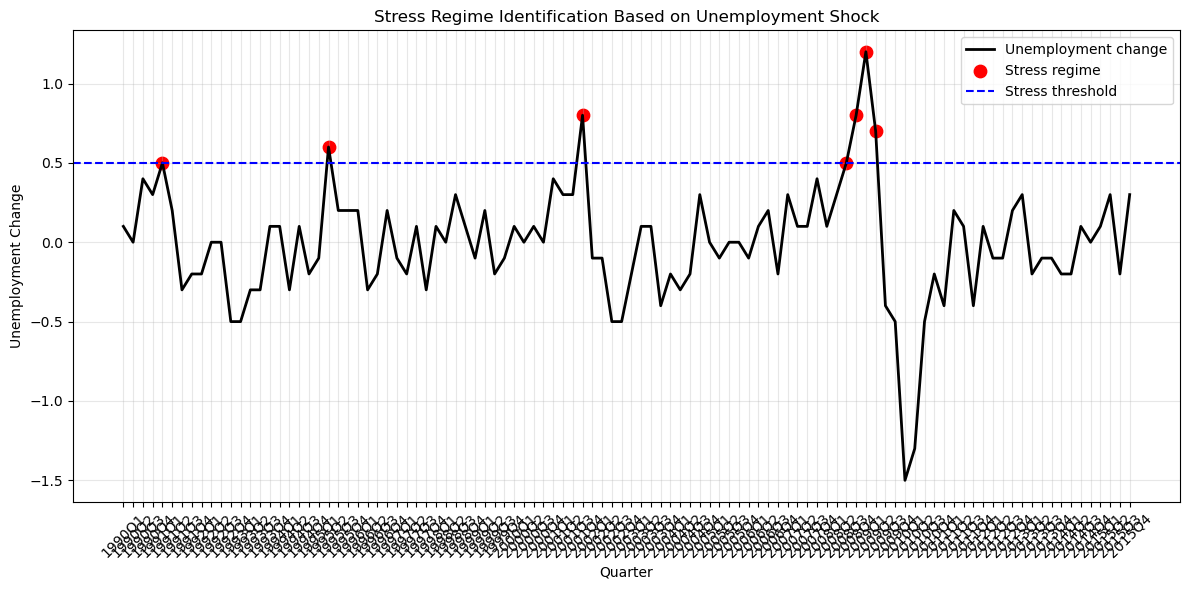

In [15]:
## VISUALISE STRESS REGIME BASED ON UNEMPLOYMENT CHANGE

import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))

# plot unemployment change
plt.plot(
    train_ext["YQ"],
    train_ext["UNRATE_change"],
    color = "black",
    linewidth = 2,
    label = "Unemployment change"
)

# mark stress periods
stress_points = train_ext[train_ext["stress_flag"] == 1]

plt.scatter(
    stress_points["YQ"],
    stress_points["UNRATE_change"],
    color = "red",
    s = 80,
    label = "Stress regime"
)

# plot threshold line
plt.axhline(
    spike_thr,
    color = "blue",
    linestyle = "--",
    label = "Stress threshold"
)

plt.xticks(rotation = 45)
plt.xlabel("Quarter")
plt.ylabel("Unemployment Change")
plt.title("Stress Regime Identification Based on Unemployment Shock")
plt.legend()
plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [16]:
## FIT EXTENDED MODEL WITH NON-FINANCIAL INDICATORS AND STRESS REGIME

train_model_regime = train_ext.dropna(subset = [
    "NGDP",
    "NGDP_lag1",
    "INDPRO_PC1",
    "INDPRO_lag1",
    "UNRATE_change",
    "stress_flag"
]).copy()


formula_regime = """
NGDP ~ NGDP_lag1
     + INDPRO_PC1
     + INDPRO_lag1
     + UNRATE_change
     + stress_flag
"""

model_regime = smf.ols(formula_regime, data = train_model_regime).fit()

print(model_regime.summary())

                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     16.71
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           7.09e-12
Time:                        18:30:11   Log-Likelihood:                -216.22
No. Observations:                 103   AIC:                             444.4
Df Residuals:                      97   BIC:                             460.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.3476      0.496      8.769

In [17]:
## RECURSIVE FORECAST USING REGIME MODEL

regime_forecast = []

last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test_ext)):

    row = test_ext.iloc[i]

    X_new = pd.DataFrame({
        "NGDP_lag1"      : [last_ngdp],
        "INDPRO_PC1"     : [row["INDPRO_PC1"]],
        "INDPRO_lag1"    : [row["INDPRO_lag1"]],
        "UNRATE_change"  : [row["UNRATE_change"]],
        "stress_flag"    : [row["stress_flag"]]
    })

    pred = model_regime.predict(X_new)[0]

    regime_forecast.append(pred)

    last_ngdp = pred


test_ext["regime_forecast"] = regime_forecast


print("Regime forecast preview:")
print(test_ext[["YQ","regime_forecast"]].head(8))
print(test_ext[["YQ","regime_forecast"]].tail(8))

Regime forecast preview:
       YQ  regime_forecast
0  2016Q1         3.663642
1  2016Q2         4.150345
2  2016Q3         4.047348
3  2016Q4         4.327839
4  2017Q1         4.395292
5  2017Q2         5.087251
6  2017Q3         4.141396
7  2017Q4         5.836470
        YQ  regime_forecast
12  2019Q1         3.854294
13  2019Q2         2.803528
14  2019Q3         3.411386
15  2019Q4         3.006258
16  2020Q1         3.157052
17  2020Q2         6.716134
18  2020Q3        -1.091493
19  2020Q4         0.724840


In [18]:
## VALIDATE REGIME MODEL

regime_validation = test_ext[["YQ","regime_forecast"]].merge(
    gdp_pca[["YQ","NGDP"]],
    on="YQ",
    how="left"
)

regime_validation.rename(columns={
    "regime_forecast":"NGDP_pred",
    "NGDP":"NGDP_actual"
}, inplace=True)


## CALCULATE PERFORMANCE METRICS

rmse_regime = np.sqrt(mean_squared_error(
    regime_validation["NGDP_actual"],
    regime_validation["NGDP_pred"]
))

mae_regime = mean_absolute_error(
    regime_validation["NGDP_actual"],
    regime_validation["NGDP_pred"]
)

print("Regime model RMSE:", round(rmse_regime,4))
print("Regime model MAE :", round(mae_regime,4))


## PREVIEW VALIDATION TABLE

print(regime_validation.head(8))
print(regime_validation.tail(8))

Regime model RMSE: 12.4098
Regime model MAE : 5.3575
       YQ  NGDP_pred  NGDP_actual
0  2016Q1   3.663642          2.0
1  2016Q2   4.150345          4.1
2  2016Q3   4.047348          3.9
3  2016Q4   4.327839          4.2
4  2017Q1   4.395292          4.1
5  2017Q2   5.087251          3.3
6  2017Q3   4.141396          5.3
7  2017Q4   5.836470          7.2
        YQ  NGDP_pred  NGDP_actual
12  2019Q1   3.854294          3.8
13  2019Q2   2.803528          5.5
14  2019Q3   3.411386          6.1
15  2019Q4   3.006258          4.0
16  2020Q1   3.157052         -3.3
17  2020Q2   6.716134        -29.1
18  2020Q3  -1.091493         39.9
19  2020Q4   0.724840          7.2


In [19]:
## COMPARE MODEL PERFORMANCE

performance_compare = pd.DataFrame({
    "Model": [
        "Base model",
        "Macro indicator model",
        "Regime model"
    ],
    "RMSE": [
        rmse_base,
        rmse_ext,
        rmse_regime
    ],
    "MAE": [
        mae_base,
        mae_ext,
        mae_regime
    ]
})

print(performance_compare)

                   Model       RMSE       MAE
0             Base model  11.117543  4.712121
1  Macro indicator model  10.475273  4.483480
2           Regime model  12.409797  5.357456


Machine Learning Models

In [20]:
## PREPARE DATA FOR MACHINE LEARNING MODELS

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# keep rows with complete variables only
train_ml = train_ext.dropna(subset = [
    "NGDP",
    "NGDP_lag1",
    "INDPRO_PC1",
    "INDPRO_lag1",
    "UNRATE_change",
    "stress_flag"
]).copy()

test_ml = test_ext.dropna(subset = [
    "INDPRO_PC1",
    "INDPRO_lag1",
    "UNRATE_change",
    "stress_flag"
]).copy()


## DEFINE FEATURE SET

features_ml = [
    "NGDP_lag1",
    "INDPRO_PC1",
    "INDPRO_lag1",
    "UNRATE_change"
]


## CREATE FULL-SAMPLE TRAINING MATRICES

X_train = train_ml[features_ml]
y_train = train_ml["NGDP"]


## SPLIT TRAINING SAMPLE BY REGIME

train_normal = train_ml[train_ml["stress_flag"] == 0].copy()
train_stress = train_ml[train_ml["stress_flag"] == 1].copy()

X_train_normal = train_normal[features_ml]
y_train_normal = train_normal["NGDP"]

X_train_stress = train_stress[features_ml]
y_train_stress = train_stress["NGDP"]


## PREVIEW SAMPLE SIZES

print("Full training sample   :", len(train_ml))
print("Normal regime sample   :", len(train_normal))
print("Stress regime sample   :", len(train_stress))

Full training sample   : 103
Normal regime sample   : 96
Stress regime sample   : 7


In [21]:
## FIT MACHINE LEARNING MODELS

# ridge regression on full sample
ridge_model = Ridge(alpha = 2.0)
ridge_model.fit(X_train, y_train)

# random forest on full sample
rf_model = RandomForestRegressor(
    n_estimators = 400,
    max_depth = 5,
    min_samples_leaf = 2,
    random_state = 42
)
rf_model.fit(X_train, y_train)


## FIT REGIME-SWITCHING XGBOOST MODELS

# normal regime model
xgb_normal = XGBRegressor(
    n_estimators = 400,
    max_depth = 3,
    learning_rate = 0.04,
    subsample = 0.90,
    colsample_bytree = 0.90,
    reg_alpha = 0.0,
    reg_lambda = 1.0,
    objective = "reg:squarederror",
    random_state = 42
)
xgb_normal.fit(X_train_normal, y_train_normal)

# stress regime model
# if too few stress rows, fit on full sample as fallback
if len(train_stress) >= 12:

    xgb_stress = XGBRegressor(
        n_estimators = 500,
        max_depth = 4,
        learning_rate = 0.05,
        subsample = 0.95,
        colsample_bytree = 0.95,
        reg_alpha = 0.0,
        reg_lambda = 1.0,
        objective = "reg:squarederror",
        random_state = 42
    )
    xgb_stress.fit(X_train_stress, y_train_stress)
    stress_model_is_real = True

else:

    xgb_stress = XGBRegressor(
        n_estimators = 450,
        max_depth = 4,
        learning_rate = 0.05,
        subsample = 0.90,
        colsample_bytree = 0.90,
        reg_alpha = 0.0,
        reg_lambda = 1.0,
        objective = "reg:squarederror",
        random_state = 42
    )
    xgb_stress.fit(X_train, y_train)
    stress_model_is_real = False

print("Stress-specific XGBoost trained on stress sample only:", stress_model_is_real)

Stress-specific XGBoost trained on stress sample only: False


In [28]:
## RECURSIVE FORECASTING WITH STRESS-AWARE REGIME BOOST MODEL

ridge_forecast = []
rf_forecast = []
xgb_regime_forecast = []
ensemble_forecast = []

last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test_ext)):

    row = test_ext.iloc[i]

    x_row = pd.DataFrame({
        "NGDP_lag1"     : [last_ngdp],
        "INDPRO_PC1"    : [row["INDPRO_PC1"]],
        "INDPRO_lag1"   : [row["INDPRO_lag1"]],
        "UNRATE_change" : [row["UNRATE_change"]]
    })

    # base model forecasts
    p_ridge = ridge_model.predict(x_row)[0]
    p_rf    = rf_model.predict(x_row)[0]

    # choose regime-specific xgboost
    stress_now = int(row["stress_flag"])

    if stress_now == 1:

        p_xgb = xgb_stress.predict(x_row)[0]

        # stronger reaction in stress periods
        pred = 0.20 * p_ridge + 0.15 * p_rf + 0.65 * p_xgb

        # optional shock amplification
        shock_adj = 0.0

        if row["UNRATE_change"] > spike_thr:
            shock_adj = -1.2 * row["UNRATE_spike"]

        pred = pred + shock_adj

        # prevent unrealistic extreme forecasts
        pred = np.clip(pred, -30, 30)

    else:

        p_xgb = xgb_normal.predict(x_row)[0]

        # more balanced weighting in normal periods
        pred = 0.20 * p_ridge + 0.20 * p_rf + 0.60 * p_xgb

    ridge_forecast.append(p_ridge)
    rf_forecast.append(p_rf)
    xgb_regime_forecast.append(p_xgb)
    ensemble_forecast.append(pred)

    # recursive update
    last_ngdp = pred


test_ext["ridge_forecast"] = ridge_forecast
test_ext["rf_forecast"] = rf_forecast
test_ext["xgb_regime_forecast"] = xgb_regime_forecast
test_ext["ensemble_forecast"] = ensemble_forecast


## PREVIEW FORECAST RESULTS

print("Stress-aware regime boost forecast preview:")
print(test_ext[[
    "YQ",
    "ridge_forecast",
    "rf_forecast",
    "xgb_regime_forecast",
    "ensemble_forecast"
]].head(8))

print(test_ext[[
    "YQ",
    "ridge_forecast",
    "rf_forecast",
    "xgb_regime_forecast",
    "ensemble_forecast"
]].tail(8))

Stress-aware regime boost forecast preview:
       YQ  ridge_forecast  rf_forecast  xgb_regime_forecast  ensemble_forecast
0  2016Q1        2.886224     4.131906             4.345612           3.801206
1  2016Q2        3.586825     3.813385             3.476387           3.624225
2  2016Q3        3.344204     2.863245             1.245789           2.464073
3  2016Q4        4.011979     4.395804             4.931916           4.455321
4  2017Q1        4.064329     3.590201             3.690506           3.778419
5  2017Q2        5.074752     4.336365             3.044979           4.132614
6  2017Q3        3.939376     4.044846             6.170717           4.740322
7  2017Q4        5.566952     4.905109             6.474279           5.658390
        YQ  ridge_forecast  rf_forecast  xgb_regime_forecast  \
12  2019Q1        3.598175     4.337445             3.774405   
13  2019Q2        2.632491     3.865302             4.632341   
14  2019Q3        2.911889     3.897960             3

In [29]:
## VALIDATE MACHINE LEARNING FORECASTS AGAINST GDP_PCA

ml_validation = test_ext[[
    "YQ",
    "ridge_forecast",
    "rf_forecast",
    "xgb_regime_forecast",
    "ensemble_forecast"
]].merge(
    gdp_pca[["YQ", "NGDP"]],
    on = "YQ",
    how = "left"
)

ml_validation.rename(columns = {
    "NGDP" : "NGDP_actual"
}, inplace = True)


## CALCULATE RMSE AND MAE

rmse_ridge = np.sqrt(mean_squared_error(
    ml_validation["NGDP_actual"],
    ml_validation["ridge_forecast"]
))
mae_ridge = mean_absolute_error(
    ml_validation["NGDP_actual"],
    ml_validation["ridge_forecast"]
)

rmse_rf = np.sqrt(mean_squared_error(
    ml_validation["NGDP_actual"],
    ml_validation["rf_forecast"]
))
mae_rf = mean_absolute_error(
    ml_validation["NGDP_actual"],
    ml_validation["rf_forecast"]
)

rmse_xgb_regime = np.sqrt(mean_squared_error(
    ml_validation["NGDP_actual"],
    ml_validation["xgb_regime_forecast"]
))
mae_xgb_regime = mean_absolute_error(
    ml_validation["NGDP_actual"],
    ml_validation["xgb_regime_forecast"]
)

rmse_ensemble = np.sqrt(mean_squared_error(
    ml_validation["NGDP_actual"],
    ml_validation["ensemble_forecast"]
))
mae_ensemble = mean_absolute_error(
    ml_validation["NGDP_actual"],
    ml_validation["ensemble_forecast"]
)

print("Ridge model RMSE      :", round(rmse_ridge, 4))
print("Ridge model MAE       :", round(mae_ridge, 4))
print("RF model RMSE         :", round(rmse_rf, 4))
print("RF model MAE          :", round(mae_rf, 4))
print("XGB regime model RMSE :", round(rmse_xgb_regime, 4))
print("XGB regime model MAE  :", round(mae_xgb_regime, 4))
print("Ensemble model RMSE   :", round(rmse_ensemble, 4))
print("Ensemble model MAE    :", round(mae_ensemble, 4))


## PREVIEW VALIDATION TABLE

print("\nMachine learning validation preview:")
print(ml_validation.head(8))
print(ml_validation.tail(8))
print("\nAny missing actual values?", ml_validation["NGDP_actual"].isna().any())

Ridge model RMSE      : 10.8223
Ridge model MAE       : 4.8279
RF model RMSE         : 10.5572
RF model MAE          : 4.7483
XGB regime model RMSE : 10.1966
XGB regime model MAE  : 4.5283
Ensemble model RMSE   : 9.2855
Ensemble model MAE    : 4.0424

Machine learning validation preview:
       YQ  ridge_forecast  rf_forecast  xgb_regime_forecast  \
0  2016Q1        2.886224     4.131906             4.345612   
1  2016Q2        3.586825     3.813385             3.476387   
2  2016Q3        3.344204     2.863245             1.245789   
3  2016Q4        4.011979     4.395804             4.931916   
4  2017Q1        4.064329     3.590201             3.690506   
5  2017Q2        5.074752     4.336365             3.044979   
6  2017Q3        3.939376     4.044846             6.170717   
7  2017Q4        5.566952     4.905109             6.474279   

   ensemble_forecast  NGDP_actual  
0           3.801206          2.0  
1           3.624225          4.1  
2           2.464073          3.9  

In [30]:
## COMPARE MODEL PERFORMANCE

performance_compare = pd.DataFrame({
    "Model" : [
        "Base model",
        "Macro indicator model",
        "Regime model",
        "Ridge model",
        "Random forest model",
        "Regime-switching XGBoost",
        "Ensemble model"
    ],
    "RMSE" : [
        rmse_base,
        rmse_ext,
        rmse_regime,
        rmse_ridge,
        rmse_rf,
        rmse_xgb_regime,
        rmse_ensemble
    ],
    "MAE" : [
        mae_base,
        mae_ext,
        mae_regime,
        mae_ridge,
        mae_rf,
        mae_xgb_regime,
        mae_ensemble
    ]
})

performance_compare["RMSE"] = performance_compare["RMSE"].round(4)
performance_compare["MAE"]  = performance_compare["MAE"].round(4)

performance_compare = performance_compare.sort_values(
    by = "RMSE"
).reset_index(drop = True)

print("\nModel Performance Comparison")
print(performance_compare)


Model Performance Comparison
                      Model     RMSE     MAE
0            Ensemble model   9.2855  4.0424
1  Regime-switching XGBoost  10.1966  4.5283
2     Macro indicator model  10.4753  4.4835
3       Random forest model  10.5572  4.7483
4               Ridge model  10.8223  4.8279
5                Base model  11.1175  4.7121
6              Regime model  12.4098  5.3575


In [31]:
## COMPUTE PERFORMANCE-WEIGHTED ENSEMBLE WEIGHTS

w_ridge = 1 / rmse_ridge
w_rf    = 1 / rmse_rf
w_xgb   = 1 / rmse_xgb_regime

w_sum = w_ridge + w_rf + w_xgb

w_ridge /= w_sum
w_rf    /= w_sum
w_xgb   /= w_sum

print("Ensemble weights:")
print("Ridge :", round(w_ridge,3))
print("RF    :", round(w_rf,3))
print("XGB   :", round(w_xgb,3))

Ensemble weights:
Ridge : 0.324
RF    : 0.332
XGB   : 0.344


In [35]:
## RECURSIVE FORECASTING WITH STRESS-AWARE REGIME BOOST MODEL

## STRESS-ADJUSTED ENSEMBLE WEIGHTS

# normal periods: use RMSE-based weights
w_ridge_normal = w_ridge
w_rf_normal    = w_rf
w_xgb_normal   = w_xgb

# stress periods: tilt more weight toward XGB
w_ridge_stress = 0.15
w_rf_stress    = 0.10
w_xgb_stress   = 0.75


ridge_forecast_boost = []
rf_forecast_boost = []
xgb_regime_forecast_boost = []
ensemble_forecast_boost = []

last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test_ext)):

    row = test_ext.iloc[i]

    x_row = pd.DataFrame({
        "NGDP_lag1"     : [last_ngdp],
        "INDPRO_PC1"    : [row["INDPRO_PC1"]],
        "INDPRO_lag1"   : [row["INDPRO_lag1"]],
        "UNRATE_change" : [row["UNRATE_change"]]
    })

    # base model forecasts
    p_ridge = ridge_model.predict(x_row)[0]
    p_rf    = rf_model.predict(x_row)[0]

    # choose regime-specific xgboost
    stress_now = int(row["stress_flag"])

    if stress_now == 1:

        p_xgb = xgb_stress.predict(x_row)[0]

        pred = (
              w_ridge_stress * p_ridge
            + w_rf_stress    * p_rf
            + w_xgb_stress   * p_xgb
        )

        # optional shock amplification
        shock_adj = 0.0

        if row["UNRATE_change"] > spike_thr:
            shock_adj = -1.2 * row["UNRATE_spike"]

        pred = pred + shock_adj

        # prevent unrealistic extreme forecasts
        pred = np.clip(pred, -30, 30)

    else:

        p_xgb = xgb_normal.predict(x_row)[0]

        pred = (
              w_ridge_normal * p_ridge
            + w_rf_normal    * p_rf
            + w_xgb_normal   * p_xgb
        )

    ridge_forecast_boost.append(p_ridge)
    rf_forecast_boost.append(p_rf)
    xgb_regime_forecast_boost.append(p_xgb)
    ensemble_forecast_boost.append(pred)

    # recursive update
    last_ngdp = pred


test_ext["ridge_forecast_boost"] = ridge_forecast_boost
test_ext["rf_forecast_boost"] = rf_forecast_boost
test_ext["xgb_regime_forecast_boost"] = xgb_regime_forecast_boost
test_ext["ensemble_forecast_boost"] = ensemble_forecast_boost


## PREVIEW FORECAST RESULTS

print("Stress-aware regime boost forecast preview:")
print(test_ext[[
    "YQ",
    "ridge_forecast_boost",
    "rf_forecast_boost",
    "xgb_regime_forecast_boost",
    "ensemble_forecast_boost"
]].head(8))

print(test_ext[[
    "YQ",
    "ridge_forecast_boost",
    "rf_forecast_boost",
    "xgb_regime_forecast_boost",
    "ensemble_forecast_boost"
]].tail(8))

Stress-aware regime boost forecast preview:
       YQ  ridge_forecast_boost  rf_forecast_boost  xgb_regime_forecast_boost  \
0  2016Q1              2.886224           4.131906                   4.345612   
1  2016Q2              3.586832           3.813385                   3.476387   
2  2016Q3              3.344202           2.863245                   1.245789   
3  2016Q4              4.011964           4.395804                   4.931916   
4  2017Q1              4.064335           3.590201                   3.690506   
5  2017Q2              5.074750           4.336365                   3.044979   
6  2017Q3              3.939362           4.044846                   6.170717   
7  2017Q4              5.566970           4.905109                   6.474279   

   ensemble_forecast_boost  
0                 3.801800  
1                 3.624098  
2                 2.462869  
3                 4.455798  
4                 3.778310  
5                 4.131522  
6                 4.741

In [36]:
## VALIDATE STRESS-AWARE REGIME BOOST FORECAST

ml_validation_boost = test_ext[[
    "YQ",
    "ridge_forecast_boost",
    "rf_forecast_boost",
    "xgb_regime_forecast_boost",
    "ensemble_forecast_boost"
]].merge(
    gdp_pca[["YQ", "NGDP"]],
    on = "YQ",
    how = "left"
)

ml_validation_boost.rename(columns = {
    "NGDP" : "NGDP_actual"
}, inplace = True)


## CALCULATE RMSE AND MAE

rmse_ensemble_boost = np.sqrt(mean_squared_error(
    ml_validation_boost["NGDP_actual"],
    ml_validation_boost["ensemble_forecast_boost"]
))

mae_ensemble_boost = mean_absolute_error(
    ml_validation_boost["NGDP_actual"],
    ml_validation_boost["ensemble_forecast_boost"]
)

print("Stress-aware ensemble RMSE:", round(rmse_ensemble_boost, 4))
print("Stress-aware ensemble MAE :", round(mae_ensemble_boost, 4))

Stress-aware ensemble RMSE: 9.2211
Stress-aware ensemble MAE : 4.0032


In [37]:
## COMPARE MODEL PERFORMANCE

performance_compare = pd.DataFrame({
    "Model" : [
        "Base model",
        "Macro indicator model",
        "Regime model",
        "Ridge model",
        "Random forest model",
        "Regime-switching XGBoost",
        "Ensemble model",
        "Stress-aware Ensemble Boost"
    ],
    "RMSE" : [
        rmse_base,
        rmse_ext,
        rmse_regime,
        rmse_ridge,
        rmse_rf,
        rmse_xgb_regime,
        rmse_ensemble,
        rmse_ensemble_boost
    ],
    "MAE" : [
        mae_base,
        mae_ext,
        mae_regime,
        mae_ridge,
        mae_rf,
        mae_xgb_regime,
        mae_ensemble,
        mae_ensemble_boost
    ]
})

performance_compare["RMSE"] = performance_compare["RMSE"].round(4)
performance_compare["MAE"]  = performance_compare["MAE"].round(4)

performance_compare = performance_compare.sort_values(
    by = "RMSE"
).reset_index(drop=True)

print("\nModel Performance Comparison")
print(performance_compare)


Model Performance Comparison
                         Model     RMSE     MAE
0  Stress-aware Ensemble Boost   9.2211  4.0032
1               Ensemble model   9.2855  4.0424
2     Regime-switching XGBoost  10.1966  4.5283
3        Macro indicator model  10.4753  4.4835
4          Random forest model  10.5572  4.7483
5                  Ridge model  10.8223  4.8279
6                   Base model  11.1175  4.7121
7                 Regime model  12.4098  5.3575


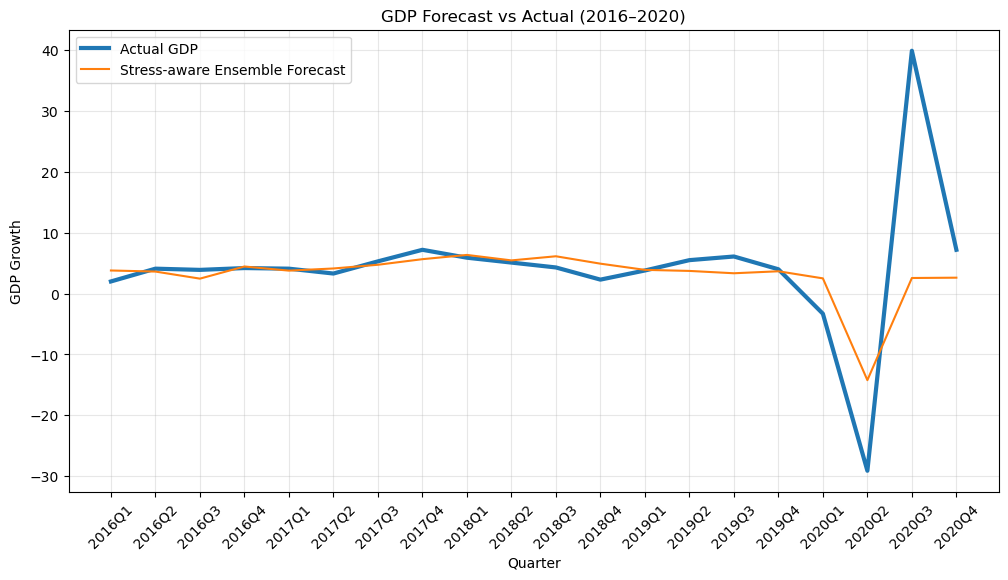

In [38]:
plt.figure(figsize=(12,6))

plt.plot(ml_validation_boost["YQ"], ml_validation_boost["NGDP_actual"],
         label="Actual GDP", linewidth=3)

plt.plot(ml_validation_boost["YQ"], ml_validation_boost["ensemble_forecast_boost"],
         label="Stress-aware Ensemble Forecast")

plt.xticks(rotation=45)
plt.xlabel("Quarter")
plt.ylabel("GDP Growth")
plt.title("GDP Forecast vs Actual (2016–2020)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
## CREATE CLASSIFICATION LABELS

y_true = (regime_validation["NGDP_actual"] < 0).astype(int)
y_pred = (regime_validation["NGDP_pred"] < 0).astype(int)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print(f"True labels: {y_true.values[:5]}")
print(f"Predicted labels: {y_pred.values[:5]}")
print(f"Accuracy: {accuracy:.4f}")

True labels: [0 0 0 0 0]
Predicted labels: [0 0 0 0 0]
Accuracy: 0.8500


In [44]:
y_true_2 = (ml_validation["NGDP_actual"] < 0).astype(int)
y_pred_2 = (ml_validation["ensemble_forecast"] < 0).astype(int)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true_2, y_pred_2)

print(f"True labels: {y_true.values[:5]}")
print(f"Predicted labels: {y_pred.values[:5]}")
print(f"Accuracy: {accuracy:.4f}")

True labels: [0 0 0 0 0]
Predicted labels: [0 0 0 0 0]
Accuracy: 0.9500


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_2, y_pred_2)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[18  0]
 [ 1  1]]
